In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy.stats import f_oneway, tukey_hsd, linregress


In [2]:
data = pd.read_csv("data.csv")

# Calculate Average and standard deviation
data["average"] = data.loc[:, "trial1" : "trial5"].mean(axis=1)
data["sd"] = data.loc[:, "trial1" : "trial5"].std(axis=1)
data = data.fillna(1.45)
data

,percentage,trial1,trial2,trial3,trial4,trial5,average,sd
0,0.0,1.9,1.0,1.45,1.45,1.45,1.45,0.636396
1,0.5,2.4,2.0,2.20,2.10,1.50,2.04,0.336155
2,1.0,2.2,2.2,2.40,1.60,1.20,1.92,0.501996
3,1.5,3.7,2.3,2.50,2.40,3.40,2.86,0.642651
4,2.0,3.8,3.4,3.20,3.00,2.30,3.14,0.554977
5,2.5,2.5,3.2,3.20,2.10,1.70,2.54,0.665582


In [3]:
long_data = data.melt(
    id_vars=["percentage"],                                     # Columns to keep as identifiers
    value_vars=["trial1", "trial2", "trial3", "trial4", "trial5"], # Columns to unpivot
    var_name="trial",                                           # Name for the new category column
    value_name="diameter"                                       # Name for the new value column
)

Text(0, 0.5, 'Diameter of Inhibition Zone')

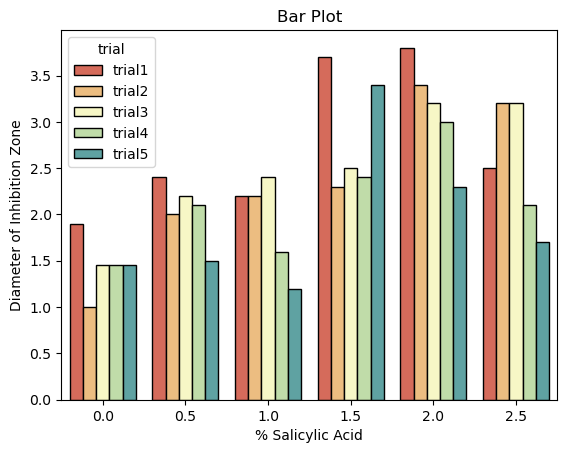

In [6]:
sns.barplot(long_data, x="percentage", y="diameter", hue="trial", palette="Spectral", edgecolor="black")

plt.title("Bar Plot")
plt.xlabel("% Salicylic Acid")
plt.ylabel("Diameter of Inhibition Zone")

<Axes: xlabel='percentage', ylabel='diameter'>

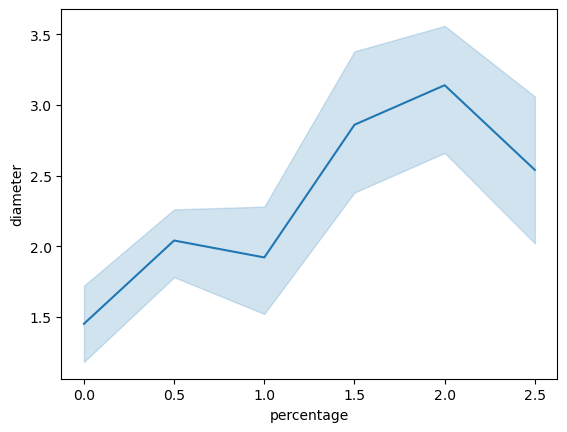

In [7]:
sns.lineplot(long_data, x="percentage", y="diameter")

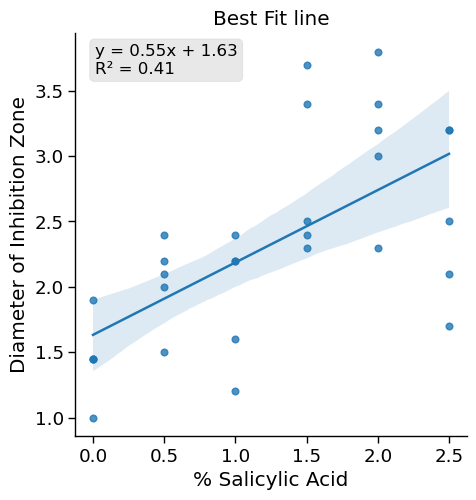

In [51]:
with sns.plotting_context("paper", font_scale=1.5):

	g = sns.lmplot(long_data, x="percentage", y="diameter")
	slope, intercept, r_value, p_value, std_err = linregress(long_data['percentage'], long_data['diameter'])
	equation_text = f'y = {slope:.2f}x + {intercept:.2f}\nR² = {r_value**2:.2f}'
	props = dict(boxstyle='round', alpha=0.5, color='lightgrey')
	g.ax.text(0.05, 0.9, equation_text, transform=g.ax.transAxes, fontsize=12, bbox=props)

	plt.title("Best Fit line")
	plt.xlabel("% Salicylic Acid")
	plt.ylabel("Diameter of Inhibition Zone")

In [8]:
## ANOVA
f_stat, p_value = f_oneway(data["trial1"], data["trial2"], data["trial3"], data["trial4"], data["trial5"])

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 1.1092
P-value: 0.3742


In [57]:
tukey_result = tukey_hsd(data["trial1"], data["trial2"], data["trial3"], data["trial4"], data["trial5"])

print(tukey_result)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.400     0.885    -0.872     1.672
 (0 - 2)      0.258     0.974    -1.013     1.530
 (0 - 3)      0.642     0.583    -0.630     1.913
 (0 - 4)      0.825     0.341    -0.447     2.097
 (1 - 0)     -0.400     0.885    -1.672     0.872
 (1 - 2)     -0.142     0.997    -1.413     1.130
 (1 - 3)      0.242     0.980    -1.030     1.513
 (1 - 4)      0.425     0.861    -0.847     1.697
 (2 - 0)     -0.258     0.974    -1.530     1.013
 (2 - 1)      0.142     0.997    -1.130     1.413
 (2 - 3)      0.383     0.900    -0.888     1.655
 (2 - 4)      0.567     0.688    -0.705     1.838
 (3 - 0)     -0.642     0.583    -1.913     0.630
 (3 - 1)     -0.242     0.980    -1.513     1.030
 (3 - 2)     -0.383     0.900    -1.655     0.888
 (3 - 4)      0.183     0.993    -1.088     1.455
 (4 - 0)     -0.825     0.341    -2.097     0.447
 (4 - 1)     -0.425     0.861    -1.697     